In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.getcwd() + '/..'))

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

from fsl_mrs.utils import misc

from matplotlib.gridspec import GridSpec
from matplotlib.widgets import CheckButtons, Button, RadioButtons

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tqdm import tqdm

In [2]:
# helper functions used throughout the analysis
def get_dataset(config):
    if 'fmrsinpain' in config['data_dir'].lower():
        from augmentrum.dataset.fmrsinpain import fMRSinPainData
        return fMRSinPainData(**config)
    elif 'brainbeats' in config['data_dir'].lower():
        from augmentrum.dataset.brainbeats import BrainBeatsData
        return BrainBeatsData(**config)
    elif 'ds006812' in config['data_dir'].lower():
        from augmentrum.dataset.cows import COWSData
        return COWSData(**config)
    else:
        raise ValueError("Dataset not recognized. Please provide a valid dataset directory.")
        
def find_ppm_indices(ppm_axis, ppm_min, ppm_max):
    return np.where((ppm_axis >= ppm_min) & (ppm_axis <= ppm_max))[0]


def baseline_correct(specs, baseline_inds):
    corrected = []
    for spec in specs:
        baseline_val = np.mean(np.real(spec[baseline_inds]))
        corrected.append(spec - baseline_val)
    return np.array(corrected)


def normalize_spectra(specs):
    return specs / np.max(np.abs(specs), axis=1, keepdims=True)


def concat_real_imag_and_select_range(specs, pca_inds):
    len_half = specs.shape[1]
    specs_concat = np.concatenate([np.real(specs), np.imag(specs)], axis=1)
    real_inds = pca_inds
    imag_inds = pca_inds + len_half
    return specs_concat[:, np.concatenate([real_inds, imag_inds])]

In [24]:
# define un-augmented and augmented data
base_config = {
    'data_dir': '../data/openneuro_ds006812/',
    'batch_size': 64,
    'val_frac': 0.0,
    'test_frac': 0.0,
    'n_coils': (None, None),
    'n_averages': (None, None),
    'cache_det': False,
    'sampling_mode': {'train': 'deterministic', 'val': 'random', 'test': 'random'},
    'to_tensor': True,
    'location': 'PARIETAL', 
    'water_sup': 'VAPOR',
    'conj': False,
    'coil_method': 'fsl-mrs'
}
dataset = get_dataset(base_config)
x, x_ref = next(iter(dataset.train_dataloader()))
x = x.squeeze(1)  # somehow has dim there

# augmented spectra
config = {
    'batch_size': 256,
    'n_coils': (8, None),
    'n_averages': (8, None),
    'sampling_mode': {'train': 'random', 'val': 'random', 'test': 'random'},
}
base_config.update(config)
dataset = get_dataset(base_config)
x_aug, x_ref_aug = next(dataset.train_dataloader())

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/128 [00:00<?, ?it/s]

...

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/128 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

read data:   0%|          | 0/128 [00:00<?, ?it/s]

read data:   0%|          | 0/64 [00:00<?, ?it/s]

In [25]:
# define plotting specifics
baseline_ppm_range = (9.5, 10.0)
pca_ppm_range = (0.5, 4.5)
max_selection = 10
sim_spectrum_ids = [f"Augmented_{i}" for i in range(x_aug.shape[0])]
perplexities = [5, 10, 15, 20, 25]

# axes = misc.calculateAxes(3000, 298029903/1E6, 1024, 4.65)
axes = misc.calculateAxes(8000, 123.259299, 4096, 4.65)
ppm_axis = axes['ppmshift']

In [26]:
# process spectra
invivo_spectra_raw = np.fft.fftshift(np.fft.fft(x.numpy(), axis=1))
sim_spectra_raw = np.fft.fftshift(np.fft.fft(x_aug.numpy(), axis=1))

baseline_indices = find_ppm_indices(ppm_axis, *baseline_ppm_range)

invivo_spectra_bc = baseline_correct(invivo_spectra_raw, baseline_indices)
sim_spectra_bc = baseline_correct(sim_spectra_raw, baseline_indices)

invivo_spectra_norm = normalize_spectra(invivo_spectra_bc)
sim_spectra_norm = normalize_spectra(sim_spectra_bc)

In [27]:
# feature Extraction (real = imag, selected ppm range)
pca_indices = find_ppm_indices(ppm_axis, *pca_ppm_range)

invivo_features = concat_real_imag_and_select_range(invivo_spectra_norm, pca_indices)
sim_features = concat_real_imag_and_select_range(sim_spectra_norm, pca_indices)

# combine spectra for analysis
all_features = np.vstack([invivo_features, sim_features])
all_features_real = all_features[:, :all_features.shape[1] // 2]  # Optional: use only real part

group_labels = np.array(['Unaltered'] * len(invivo_features) + ['Augmented'] * len(sim_features))
spectrum_labels = np.array(
    [f"Unaltered_{i}" for i in range(len(invivo_features))] + sim_spectrum_ids
)

In [28]:
# PCA + t-SNE
scaler = StandardScaler()
scaled_features = scaler.fit_transform(all_features_real)

pca = PCA(n_components=0.95)
pca_features = pca.fit_transform(scaled_features)

tsne_results = {}
for perplexity in tqdm(perplexities):
    tsne = TSNE(n_components=2, perplexity=perplexity, init='random', random_state=42, max_iter=1000)
    tsne_coords = tsne.fit_transform(pca_features)
    tsne_results[perplexity] = tsne_coords

100%|█████████████████████████████████████████████████████████████████| 5/5 [00:05<00:00,  1.10s/it]


/var/folders/3m/ry9cxhhs3g9_p48nkvk2xpjc0000gn/T/ipykernel_38968/2867449941.py:88: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_spec.legend()


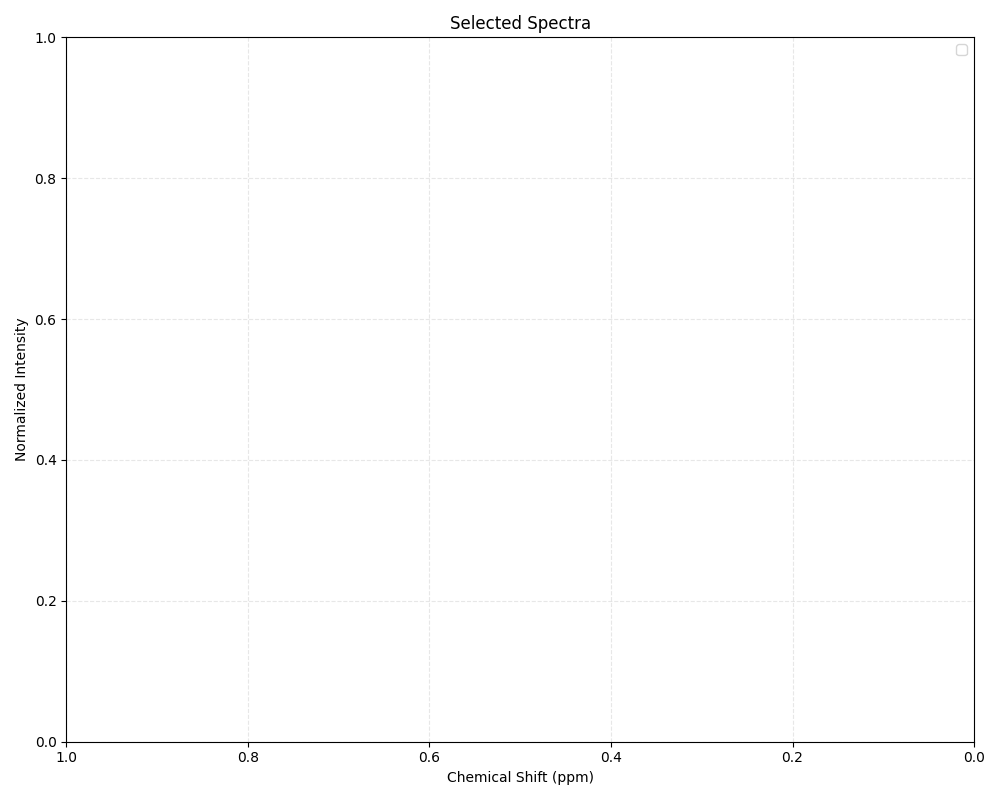

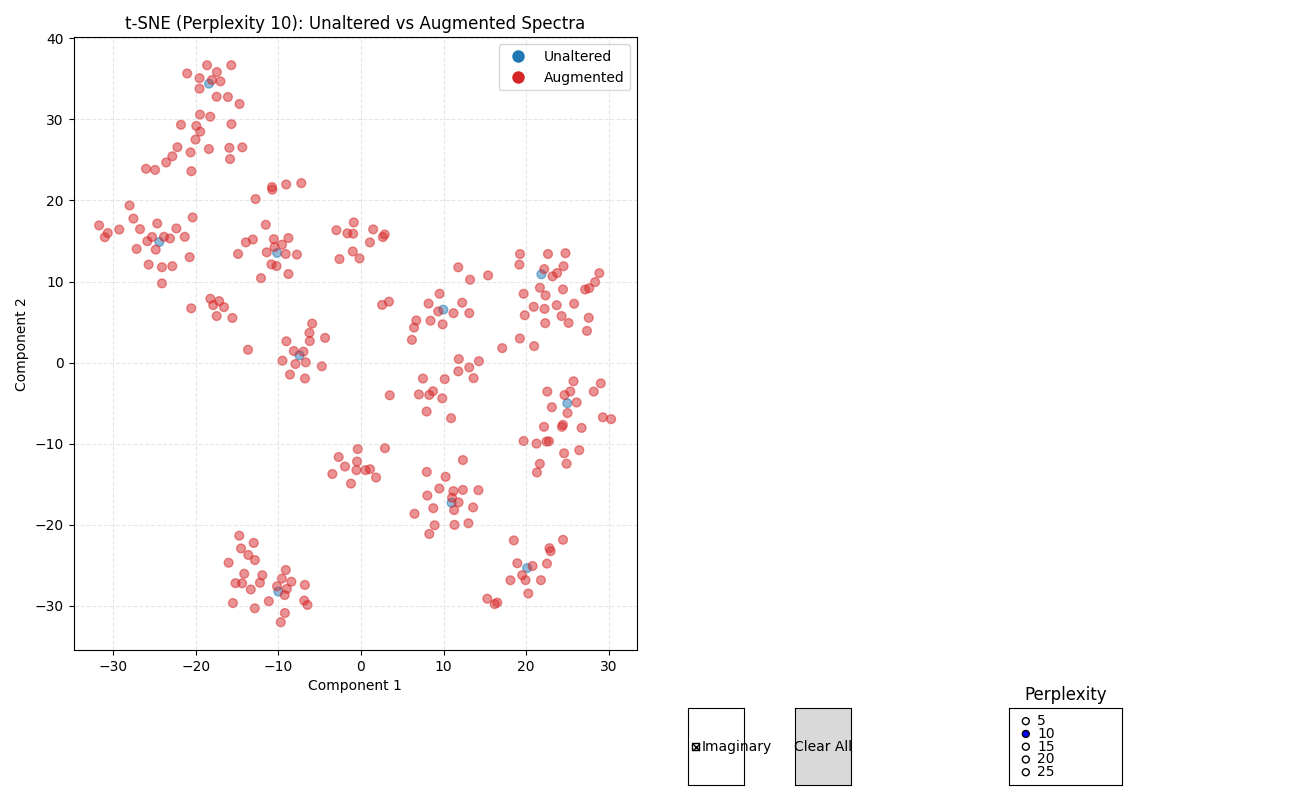

In [29]:
%matplotlib widget

# Simplified color scheme
selection_colors = {
    'Unaltered': '#1f77b4',          # deep blue
    'Augmented': '#d62728',        # crimson red
    'highlight_inviv': '#aec7e8',  # light blue for highlight
    'highlight_sim': '#ff9896',    # light red for highlight
}

# === Setup figure ===
fig = plt.figure(figsize=(13, 8))
gs = GridSpec(2, 6, height_ratios=[8, 1], width_ratios=[5, 0.5, 0.5, 0.5, 1, 1])
ax_tsne = fig.add_subplot(gs[0, 0])

# === Initial t-SNE data ===
current_perplexity = perplexities[1]
tsne_coords = tsne_results[current_perplexity]

# === t-SNE Scatter ===
color_map = {key: selection_colors[key] for key in ['Unaltered', 'Augmented']}

point_colors = [color_map.get(label, '#cccccc') for label in group_labels]

sc = ax_tsne.scatter(tsne_coords[:, 0], tsne_coords[:, 1],
                     c=point_colors, alpha=0.5, s=40)
ax_tsne.set_title(f't-SNE (Perplexity {current_perplexity}): Unaltered vs Augmented Spectra')
ax_tsne.set_xlabel('Component 1')
ax_tsne.set_ylabel('Component 2')
ax_tsne.grid(True, linestyle='--', alpha=0.3)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Unaltered', markerfacecolor=selection_colors['Unaltered'], markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Augmented', markerfacecolor=selection_colors['Augmented'], markersize=10),
]
ax_tsne.legend(handles=legend_elements, loc='upper right')

# Highlight marker, initially empty
highlight_marker = ax_tsne.scatter([], [], facecolors='none', edgecolors='black', s=120, linewidths=2)

# === Spectrum plot ===
fig_spec, ax_spec = plt.subplots(figsize=(10, 8))
selected_spectra = []
imaginary_visible = [True]

def update_spectrum_plot():
    ax_spec.clear()

    # Separate selected indices by class
    invivo_indices = [idx for idx in selected_spectra if group_labels[idx] == 'Unaltered']
    sim_indices = [idx for idx in selected_spectra if group_labels[idx] == 'Augmented']

    # Generate color gradients for each class
    invivo_cmap = cm.Blues
    sim_cmap = cm.Reds

    # Create line colors spaced evenly in the colormap (avoid extremes)
    invivo_colors = [invivo_cmap(0.3 + 0.7 * i / max(1, len(invivo_indices)-1)) for i in range(len(invivo_indices))]
    sim_colors = [sim_cmap(0.3 + 0.7 * i / max(1, len(sim_indices)-1)) for i in range(len(sim_indices))]

    # Plot Unaltered spectra
    for i, idx in enumerate(invivo_indices):
        spectrum = all_features[idx]
        mid = len(spectrum) // 2
        real = spectrum[:mid]
        imag = spectrum[mid:]
        ppm = ppm_axis[pca_indices]

        ax_spec.plot(ppm, real, label=spectrum_labels[idx], color=invivo_colors[i])
        if imaginary_visible[0]:
            ax_spec.plot(ppm, imag, '--', color=invivo_colors[i], alpha=0.6)

    # Plot Augmented spectra
    for i, idx in enumerate(sim_indices):
        spectrum = all_features[idx]
        mid = len(spectrum) // 2
        real = spectrum[:mid]
        imag = spectrum[mid:]
        ppm = ppm_axis[pca_indices]

        ax_spec.plot(ppm, real, label=spectrum_labels[idx], color=sim_colors[i])
        if imaginary_visible[0]:
            ax_spec.plot(ppm, imag, '--', color=sim_colors[i], alpha=0.6)

    ax_spec.set_title("Selected Spectra")
    ax_spec.set_xlabel("Chemical Shift (ppm)")
    ax_spec.set_ylabel("Normalized Intensity")
    ax_spec.legend()
    ax_spec.grid(True, linestyle='--', alpha=0.3)
    ax_spec.invert_xaxis()
    fig_spec.tight_layout()
    fig_spec.canvas.draw()

    # Update highlight markers (keep as before)
    if selected_spectra:
        coords = tsne_coords[selected_spectra]
        highlight_colors = []
        for idx in selected_spectra:
            label = group_labels[idx]
            if label == 'Unaltered':
                highlight_colors.append(selection_colors['highlight_inviv'])
            else:
                highlight_colors.append(selection_colors['highlight_sim'])
        highlight_marker.set_offsets(coords)
        highlight_marker.set_facecolors(highlight_colors)
        highlight_marker.set_edgecolors('black')
    else:
        highlight_marker.set_offsets(np.empty((0, 2)))
        highlight_marker.set_facecolors([])
        highlight_marker.set_edgecolors([])


def toggle_imaginary(label):
    imaginary_visible[0] = not imaginary_visible[0]
    update_spectrum_plot()

def clear_selection(event):
    selected_spectra.clear()
    update_spectrum_plot()

def on_tsne_click(event):
    if event.inaxes != ax_tsne:
        return
    dist = np.linalg.norm(tsne_coords - [event.xdata, event.ydata], axis=1)
    idx = np.argmin(dist)
    if idx in selected_spectra:
        selected_spectra.remove(idx)
    elif len(selected_spectra) < 10:
        selected_spectra.append(idx)
    else:
        print("Maximum of 10 spectra.")
    update_spectrum_plot()

def update_tsne_plot(label):
    global tsne_coords, current_perplexity
    current_perplexity = int(label)
    tsne_coords = tsne_results[current_perplexity]

    sc.set_offsets(tsne_coords)
    ax_tsne.set_title(f't-SNE (Perplexity {current_perplexity}): Unaltered vs Augmented Spectra')

    # Axis padding
    padding = 5  # percent
    x_min, x_max = tsne_coords[:, 0].min(), tsne_coords[:, 0].max()
    y_min, y_max = tsne_coords[:, 1].min(), tsne_coords[:, 1].max()
    x_pad = (x_max - x_min) * padding / 100
    y_pad = (y_max - y_min) * padding / 100

    ax_tsne.set_xlim(x_min - x_pad, x_max + x_pad)
    ax_tsne.set_ylim(y_min - y_pad, y_max + y_pad)

    update_spectrum_plot()
    fig.canvas.draw_idle()

# === Controls below ===
check_ax = fig.add_subplot(gs[1, 1])
imaginary_checkbox = CheckButtons(check_ax, ['Imaginary'], [True])
imaginary_checkbox.on_clicked(toggle_imaginary)

clear_ax = fig.add_subplot(gs[1, 2])
clear_btn = Button(clear_ax, 'Clear All')
clear_btn.on_clicked(clear_selection)

radio_ax = fig.add_subplot(gs[1, 4])
radio = RadioButtons(radio_ax, [str(p) for p in perplexities])
radio.on_clicked(update_tsne_plot)
radio.set_active(1)  # Set initial active perplexity
radio_ax.set_title("Perplexity")

fig.canvas.mpl_connect('button_press_event', on_tsne_click)
fig.tight_layout()
plt.show()